# Padel Stroke Classification from Video (I3D · SlowFast · TimeSformer)

This notebook benchmarks three video models on the padel stroke dataset: **I3D** (inflated 3D CNN), **SlowFast** (two-pathway networks), and **TimeSformer** (video transformer). Videos are cropped to bounding boxes around the action region. All models start from pretrained weights and are fine-tuned on the filtered dataset.

## Roadmap
1. **Load & filter dataset** – Load bounding boxes, filter classes (≥10 samples, merge Vibora+Bandeja, exclude Lob)
2. **Train/val/test split** – Stratified split with seed for reproducibility
3. **Video dataset** – Crop videos to bounding boxes, uniform temporal sampling
4. **I3D baseline** – Fine-tune `i3d_r50` pretrained on Kinetics-400
5. **SlowFast baseline** – Fine-tune `slowfast_r50` pretrained on Kinetics-400
6. **TimeSformer baseline** – Fine-tune `timesformer_base` pretrained on K400
7. **Evaluation** – Test set metrics, confusion matrices, per-class accuracy

In [1]:
import sys
if 'google.colab' in sys.modules:
    %pip install -q torch torchvision pytorchvideo timm transformers google-cloud-storage

    # Authenticate with Google Cloud (for Colab)
    from google.colab import auth
    auth.authenticate_user()
    print('✓ Authenticated with Google Cloud')
else:
    print('✓ Using local environment')

✓ Authenticated with Google Cloud


In [2]:
import random
from pathlib import Path
import time
import json
import datetime

import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from transformers import TimesformerForVideoClassification

try:
    from pytorchvideo.models.hub import i3d_r50
except ImportError as e:
    print(f'⚠ {e}')
    print('⚠ pytorchvideo not installed. Run: pip install pytorchvideo')

# GCS bucket configuration
GCS_BUCKET = 'padel-cv-dataset'
GCS_VIDEO_PREFIX = 'video'
GCS_WEIGHTS_PREFIX = 'weights'

# Path configuration
if 'google.colab' in sys.modules:
    DATASET_ROOT = Path('/content/dataset').resolve()
    ARTIFACTS_ROOT = Path('/content/artifacts')
else:
    DATASET_ROOT = Path('../dataset').resolve()
    ARTIFACTS_ROOT = Path('../artifacts')

BBOX_CSV = DATASET_ROOT / 'bboxes.csv'
ARTIFACTS = ARTIFACTS_ROOT / 'stroke_classification_video'
VIDEO_CLIP_CACHE = ARTIFACTS_ROOT / 'preprocessed_video_clips'

# Create directories
ARTIFACTS.mkdir(parents=True, exist_ok=True)
VIDEO_CLIP_CACHE.mkdir(parents=True, exist_ok=True)

# Set random seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# For deterministic behavior (may impact performance)
# if torch.cuda.is_available():
#     torch.cuda.manual_seed_all(SEED)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## 0. Download dataset from GCS (Colab only)
Download the dataset from Google Cloud Storage if running on Colab and dataset doesn't exist locally.

In [3]:
# Download dataset from GCS if needed (Colab only)
if 'google.colab' in sys.modules and not BBOX_CSV.exists():
    print(f'Dataset not found locally. Downloading from gs://{GCS_BUCKET}/{GCS_VIDEO_PREFIX}/')

    from google.cloud import storage

    # Initialize GCS client
    client = storage.Client()
    bucket = client.bucket(GCS_BUCKET)

    # Create local dataset directory
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)

    # List all files under the video prefix
    blobs = bucket.list_blobs(prefix=GCS_VIDEO_PREFIX)

    downloaded = 0
    for blob in blobs:
        if blob.name.endswith('/'):
            continue

        # Extract relative path (remove 'video/' prefix)
        rel_path = blob.name[len(GCS_VIDEO_PREFIX)+1:] if blob.name.startswith(GCS_VIDEO_PREFIX + '/') else blob.name
        local_path = DATASET_ROOT / rel_path

        # Create parent directory
        local_path.parent.mkdir(parents=True, exist_ok=True)

        # Download file
        blob.download_to_filename(str(local_path))
        downloaded += 1

        if downloaded % 10 == 0:
            print(f'  Downloaded {downloaded} files...')

    print(f'✓ Downloaded {downloaded} files from GCS')
    print(f'✓ Dataset ready at: {DATASET_ROOT}')
else:
    print(f'✓ Dataset already available at: {DATASET_ROOT}')

✓ Dataset already available at: /content/dataset


## 1. Load and filter dataset
Load bounding boxes and apply class filters: keep classes with ≥10 samples, merge Vibora+Bandeja, exclude Lob.

In [4]:
# Load bounding boxes
bboxes_df = pd.read_csv(BBOX_CSV)

# Fix paths for current environment
if 'google.colab' in sys.modules:
    # On Colab, videos are under /content/dataset/
    bboxes_df['video'] = bboxes_df['video'].apply(
        lambda x: str(DATASET_ROOT / Path(x).parent.name / Path(x).name)
    )
else:
    # Local: maintain relative paths from dataset root
    bboxes_df['video'] = bboxes_df['video'].apply(lambda x: str((DATASET_ROOT.parent / x).resolve()))

bboxes_df['stroke'] = bboxes_df['video'].apply(lambda x: Path(x).parent.name)

# Class filtering
print('Original class distribution:')
class_counts = bboxes_df['stroke'].value_counts()
print(class_counts)

# FIRST: Merge Vibora + Bandeja -> Vibora_Bandeja (before filtering)
bboxes_df['stroke'] = bboxes_df['stroke'].replace({'Vibora': 'Vibora_Bandeja', 'Bandeja': 'Vibora_Bandeja'})

# THEN: Filter - keep classes with >= 10 samples
class_counts_merged = bboxes_df['stroke'].value_counts()
valid_classes = class_counts_merged[class_counts_merged >= 10].index.tolist()
bboxes_df = bboxes_df[bboxes_df['stroke'].isin(valid_classes)].copy()

# FINALLY: Exclude Lob
bboxes_df = bboxes_df[bboxes_df['stroke'] != 'Lob'].copy()

print('\nFiltered class distribution:')
print(bboxes_df['stroke'].value_counts())
print(f'\nTotal samples: {len(bboxes_df)}')

Original class distribution:
stroke
Backhand_Volley    42
Smash              39
Forehand_Volley    39
Backhand           36
Forehand           33
Vibora             24
Lob                21
Bandeja             8
Contrapared         3
Dropshot            1
Name: count, dtype: int64

Filtered class distribution:
stroke
Backhand_Volley    42
Smash              39
Forehand_Volley    39
Backhand           36
Forehand           33
Vibora_Bandeja     32
Name: count, dtype: int64

Total samples: 221


## 2. Train/val/test split
Stratified split: 70% train, 20% val, 10% test.

In [5]:
train_df, temp_df = train_test_split(
    bboxes_df, test_size=0.3, stratify=bboxes_df['stroke'], random_state=SEED
)
val_df, test_df = train_test_split(
    temp_df, test_size=0.3333, stratify=temp_df['stroke'], random_state=SEED
)

# Save original indices before reset (for later clip_path mapping)
train_df['original_idx'] = train_df.index
val_df['original_idx'] = val_df.index
test_df['original_idx'] = test_df.index

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}')
print('\nTrain distribution:')
print(train_df['stroke'].value_counts())

Train: 154, Val: 44, Test: 23

Train distribution:
stroke
Backhand_Volley    29
Smash              27
Forehand_Volley    27
Backhand           25
Vibora_Bandeja     23
Forehand           23
Name: count, dtype: int64


## 3. Determine clip length from frame distribution
Analyze the frame count distribution to determine optimal clip length (90th percentile).

Frame count statistics:
  Min: 9
  Max: 26
  Mean: 16.4
  Median: 17.0
  25th percentile: 14.0
  75th percentile: 19.0

Using CLIP_LEN = 20 frames


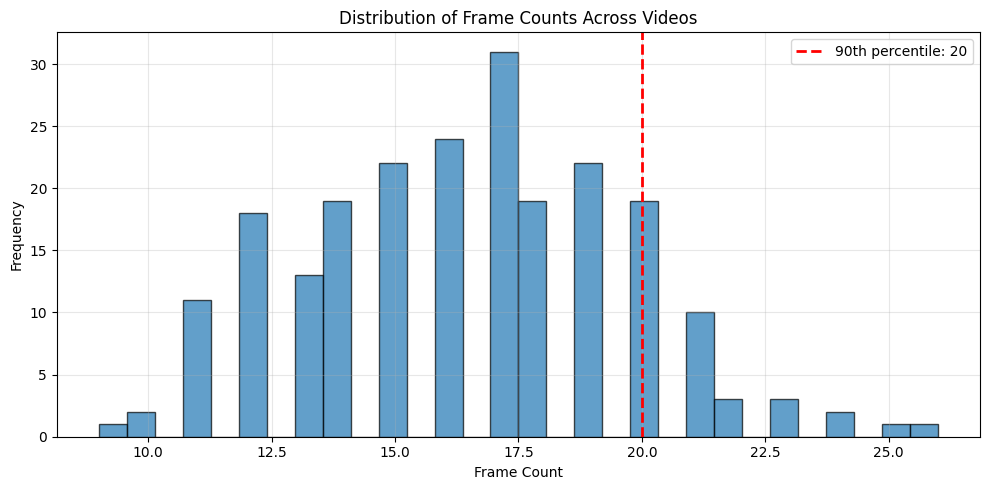

In [6]:
# Analyze frame counts across all videos
frame_counts = []
for video_path in bboxes_df['video'].unique():
    cap = cv2.VideoCapture(video_path)
    frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    cap.release()
    frame_counts.append(frame_count)

frame_counts = np.array(frame_counts)

print('Frame count statistics:')
print(f'  Min: {frame_counts.min()}')
print(f'  Max: {frame_counts.max()}')
print(f'  Mean: {frame_counts.mean():.1f}')
print(f'  Median: {np.median(frame_counts):.1f}')
print(f'  25th percentile: {np.percentile(frame_counts, 25):.1f}')
print(f'  75th percentile: {np.percentile(frame_counts, 75):.1f}')

# Use 90th percentile to accommodate most videos
CLIP_LEN = int(np.percentile(frame_counts, 90))
print(f'\nUsing CLIP_LEN = {CLIP_LEN} frames')

# Visualize
plt.figure(figsize=(10, 5))
plt.hist(frame_counts, bins=30, alpha=0.7, edgecolor='black')
plt.axvline(CLIP_LEN, color='red', linestyle='--', label=f'90th percentile: {CLIP_LEN}', linewidth=2)
plt.xlabel('Frame Count')
plt.ylabel('Frequency')
plt.title('Distribution of Frame Counts Across Videos')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3.5. Pre-extract video clips to disk
Pre-process all videos (crop to bbox, resize, sample frames) and save to disk for faster training.

In [7]:
def extract_and_save_clip(row, num_frames, target_size, cache_dir):
    """Extract, crop, resize a video clip and save to disk."""
    video_path = row['video']
    x, y, w, h = row['x'], row['y'], row['width'], row['height']

    # Generate unique cache filename
    video_name = Path(video_path).stem
    cache_file = cache_dir / f"{video_name}.npy"

    # Skip if already cached
    if cache_file.exists():
        return cache_file

    # Load video and extract bounding box region
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    # Convert percentages to pixels
    x_px = int(x * video_width / 100)
    y_px = int(y * video_height / 100)
    w_px = int(w * video_width / 100)
    h_px = int(h * video_height / 100)

    # Uniform temporal sampling
    frame_indices = np.linspace(0, total_frames - 1, num_frames, dtype=int)
    frames = []

    for frame_idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            frame = np.zeros((video_height, video_width, 3), dtype=np.uint8)

        # Crop to bounding box
        frame_crop = frame[y_px:y_px+h_px, x_px:x_px+w_px]

        # Resize to target size
        if frame_crop.size > 0:
            frame_crop = cv2.resize(frame_crop, (target_size, target_size))
        else:
            frame_crop = np.zeros((target_size, target_size, 3), dtype=np.uint8)

        # BGR to RGB
        frame_crop = cv2.cvtColor(frame_crop, cv2.COLOR_BGR2RGB)
        frames.append(frame_crop)

    cap.release()

    # Stack frames: (T, H, W, C)
    clip_array = np.stack(frames, axis=0).astype(np.uint8)

    # Save to disk
    np.save(cache_file, clip_array)

    return cache_file

# Pre-extract all clips
print(f'Pre-extracting {len(bboxes_df)} video clips...')
print(f'Cache directory: {VIDEO_CLIP_CACHE}')

clip_paths = []
for idx, row in tqdm(bboxes_df.iterrows(), total=len(bboxes_df), desc='Extracting clips'):
    clip_path = extract_and_save_clip(row, CLIP_LEN, 224, VIDEO_CLIP_CACHE)
    clip_paths.append(str(clip_path))

# Add clip paths to dataframe
bboxes_df['clip_path'] = clip_paths

print(f'✓ Pre-extraction complete. {len(clip_paths)} clips saved to disk.')

# Update train/val/test dataframes with clip paths using original indices
train_df['clip_path'] = train_df['original_idx'].map(lambda idx: bboxes_df.loc[idx, 'clip_path'])
val_df['clip_path'] = val_df['original_idx'].map(lambda idx: bboxes_df.loc[idx, 'clip_path'])
test_df['clip_path'] = test_df['original_idx'].map(lambda idx: bboxes_df.loc[idx, 'clip_path'])

# Drop the temporary original_idx column
train_df = train_df.drop(columns=['original_idx'])
val_df = val_df.drop(columns=['original_idx'])
test_df = test_df.drop(columns=['original_idx'])

print(f'Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}\n')
print(f'Train classes: {sorted(train_df["stroke"].unique())}')
print(f'Val classes: {sorted(val_df["stroke"].unique())}')
print(f'Test classes: {sorted(test_df["stroke"].unique())}')

Pre-extracting 221 video clips...
Cache directory: /content/artifacts/preprocessed_video_clips


Extracting clips:   0%|          | 0/221 [00:00<?, ?it/s]

✓ Pre-extraction complete. 221 clips saved to disk.
Train: 154, Val: 44, Test: 23

Train classes: ['Backhand', 'Backhand_Volley', 'Forehand', 'Forehand_Volley', 'Smash', 'Vibora_Bandeja']
Val classes: ['Backhand', 'Backhand_Volley', 'Forehand', 'Forehand_Volley', 'Smash', 'Vibora_Bandeja']
Test classes: ['Backhand', 'Backhand_Volley', 'Forehand', 'Forehand_Volley', 'Smash', 'Vibora_Bandeja']


## 4. Data augmentation for video
Video augmentation: horizontal flips, scale, and rotations applied to frames.

In [8]:
class VideoAugmentation:
    """Video augmentation for training: horizontal flip, scale, rotation."""

    def __init__(self, p_flip=0.5, scale_range=(0.9, 1.1), rotation_range=(-10, 10)):
        self.p_flip = p_flip
        self.scale_range = scale_range
        self.rotation_range = rotation_range

    def __call__(self, video_tensor):
        """
        Args:
            video_tensor: (C, T, H, W) tensor
        Returns:
            Augmented (C, T, H, W) tensor
        """
        C, T, H, W = video_tensor.shape

        # Horizontal flip
        if random.random() < self.p_flip:
            video_tensor = torch.flip(video_tensor, dims=[3])  # Flip width dimension

        # Scale and rotation (apply to all frames)
        if random.random() < 0.5:
            scale = random.uniform(*self.scale_range)
            angle = random.uniform(*self.rotation_range)

            # Convert to numpy for cv2 operations
            frames = []
            for t in range(T):
                frame = video_tensor[:, t, :, :].permute(1, 2, 0).cpu().numpy()  # (H, W, C)

                # Get rotation matrix
                center = (W // 2, H // 2)
                M = cv2.getRotationMatrix2D(center, angle, scale)

                # Apply transformation
                frame = cv2.warpAffine(frame, M, (W, H), borderMode=cv2.BORDER_REFLECT)
                frames.append(frame)

            # Convert back to tensor
            video_tensor = torch.from_numpy(np.stack(frames)).permute(3, 0, 1, 2).float()

        return video_tensor

print('✓ Video augmentation defined')

✓ Video augmentation defined


## 5. Video dataset (optimized - loads pre-extracted clips)
Load pre-extracted video clips from disk for fast training.

In [9]:
class PadelVideoDataset(Dataset):
    """Dataset that loads pre-extracted video clips from disk."""

    def __init__(self, df: pd.DataFrame, augment: bool = False):
        self.df = df.reset_index(drop=True)
        self.augment = augment
        self.labels = sorted(df['stroke'].unique())
        self.label2idx = {label: idx for idx, label in enumerate(self.labels)}
        self.idx2label = {idx: label for label, idx in self.label2idx.items()}

        # Augmentation
        if augment:
            self.aug = VideoAugmentation(p_flip=0.5, scale_range=(0.9, 1.1), rotation_range=(-10, 10))
        else:
            self.aug = None

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        clip_path = row['clip_path']
        label = self.label2idx[row['stroke']]

        # Load pre-extracted clip from disk (FAST!)
        clip_array = np.load(clip_path)  # (T, H, W, C), uint8

        # Convert to tensor: (T, H, W, C) -> (C, T, H, W)
        video_tensor = torch.from_numpy(clip_array).permute(3, 0, 1, 2).float() / 255.0

        # Normalize (ImageNet stats)
        mean = torch.tensor([0.45, 0.45, 0.45]).view(3, 1, 1, 1)
        std = torch.tensor([0.225, 0.225, 0.225]).view(3, 1, 1, 1)
        video_tensor = (video_tensor - mean) / std

        # Apply augmentation if training
        if self.aug is not None:
            video_tensor = self.aug(video_tensor)

        return video_tensor, label

# Create datasets (with augmentation for training)
train_dataset = PadelVideoDataset(train_df, augment=True)
val_dataset = PadelVideoDataset(val_df, augment=False)
test_dataset = PadelVideoDataset(test_df, augment=False)

print(f'Datasets created using pre-extracted clips')
print(f'Training dataset: augmentation enabled')
print(f'Validation/test datasets: no augmentation')
print(f'Classes: {train_dataset.labels}')
print(f'Number of classes: {len(train_dataset.labels)}')

Datasets created using pre-extracted clips
Training dataset: augmentation enabled
Validation/test datasets: no augmentation
Classes: ['Backhand', 'Backhand_Volley', 'Forehand', 'Forehand_Volley', 'Smash', 'Vibora_Bandeja']
Number of classes: 6


## 6. Training and evaluation utilities
Shared functions for training loops and evaluation with early stopping.

In [10]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    for videos, labels in loader:
        videos, labels = videos.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(videos)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * videos.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return total_loss / total, correct / total

def eval_epoch(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for videos, labels in loader:
            videos, labels = videos.to(device), labels.to(device)
            outputs = model(videos)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * videos.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_loss / total, correct / total, np.array(all_preds), np.array(all_labels)

def train_model(model, train_loader, val_loader, epochs=20, lr=1e-4, model_name='model', patience=7):
    criterion = nn.CrossEntropyLoss()
    optimizer = AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    best_epoch = 0
    best_model_path = ARTIFACTS / f'{model_name}_best.pth'
    patience_counter = 0

    # Track history
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
        'lr': [],
        'best_epoch': 0,
        'stopped_early': False,
        'training_time': 0.0
    }

    # Start timing
    start_time = time.time()

    for epoch in range(epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = eval_epoch(model, val_loader, criterion, device)
        current_lr = optimizer.param_groups[0]['lr']
        scheduler.step()

        # Store history
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        history['lr'].append(current_lr)

        print(f'Epoch {epoch+1:02d}/{epochs}  loss: {train_loss:.4f} - acc: {train_acc:.4f} - val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f} - lr: {current_lr:.2e}', end='')

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_epoch = epoch
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(' **')
        else:
            patience_counter += 1
            print()

        # Early stopping
        if patience_counter >= patience:
            print(f'\nEarly stopping triggered after {epoch + 1} epochs (patience={patience})')
            history['stopped_early'] = True
            break

    # Load best model
    model.load_state_dict(torch.load(best_model_path))

    # Calculate total training time
    total_time = time.time() - start_time
    history['training_time'] = total_time
    history['best_epoch'] = best_epoch

    print(f'\nBest validation accuracy: {best_val_acc:.3f} (epoch {best_epoch + 1})')
    print(f'Total training time: {total_time/60:.2f} minutes ({total_time:.1f} seconds)')
    return model, history

def plot_training_curves(history, model_name):
    """Plot loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    best_epoch = history.get('best_epoch', 0)
    stopped_early = history.get('stopped_early', False)

    # Loss curve
    axes[0].plot(history['train_loss'], label='Loss de Entrenamiento', marker='o')
    axes[0].plot(history['val_loss'], label='Loss de Validación', marker='s')
    axes[0].axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Mejor Modelo (Epoch {best_epoch + 1})')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    title_suffix = ' - Early Stopping' if stopped_early else ''
    axes[0].set_title(f'Loss de Entrenamiento y Validación ({model_name}){title_suffix}')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Accuracy curve
    axes[1].plot(history['train_acc'], label='Acc de Entrenamiento', marker='o')
    axes[1].plot(history['val_acc'], label='Acc de Validación', marker='s')
    axes[1].axvline(x=best_epoch, color='red', linestyle='--', linewidth=2, label=f'Mejor Modelo (Epoch {best_epoch + 1})')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title(f'Accuracy de Entrenamiento y Validación ({model_name}){title_suffix}')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

def evaluate_model(model, loader, class_names, device, model_name='Model'):
    """Evaluate model and show metrics."""
    criterion = nn.CrossEntropyLoss()

    # Time inference
    start_time = time.time()
    test_loss, test_acc, preds, labels = eval_epoch(model, loader, criterion, device)
    inference_time = time.time() - start_time

    print(f'\n{"="*60}')
    print(f'{model_name} - Test Set Evaluation')
    print(f'{"="*60}')
    print(f'Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.3f}')
    print(f'Inference Time: {inference_time:.2f} seconds ({inference_time/len(loader.dataset)*1000:.2f} ms/sample)')

    # Get all class indices
    all_labels = list(range(len(class_names)))

    # Classification report
    print('\nClassification Report:')
    print(classification_report(labels, preds, labels=all_labels, target_names=class_names, digits=3, zero_division=0))

    # Confusion matrix
    cm = confusion_matrix(labels, preds, labels=all_labels)
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    # Confusion matrix heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_xlabel('Predicho')
    axes[0].set_ylabel('Verdadero')
    axes[0].set_title(f'Matriz de Confusión ({model_name})')

    # Per-class accuracy
    per_class_acc = cm.diagonal() / cm.sum(axis=1)
    avg_class_acc = per_class_acc.mean()

    axes[1].barh(class_names, per_class_acc, color='steelblue')
    axes[1].axvline(x=avg_class_acc, color='red', linestyle='--', linewidth=2, label=f'Promedio: {avg_class_acc:.3f}')
    axes[1].set_xlabel('Accuracy')
    axes[1].set_title(f'Accuracy por Clase ({model_name})')
    axes[1].set_xlim([0, 1])
    axes[1].legend()
    for i, v in enumerate(per_class_acc):
        axes[1].text(v + 0.02, i, f'{v:.3f}', va='center')

    plt.tight_layout()
    plt.show()

    return test_acc, per_class_acc, inference_time

def save_and_upload_model(model, model_name, history, test_acc, per_class_acc, inference_time, class_names):
    """Save model weights and upload to GCS."""
    # Save model weights locally
    model_path = ARTIFACTS / f'{model_name}_final.pth'
    torch.save(model.state_dict(), model_path)
    print(f'✓ Model saved locally: {model_path}')

    # Save metadata
    metadata = {
        'model_name': model_name,
        'timestamp': datetime.datetime.now().isoformat(),
        'test_accuracy': float(test_acc),
        'per_class_accuracy': {cls: float(per_class_acc[i]) for i, cls in enumerate(class_names)},
        'best_val_accuracy': float(max(history['val_acc'])),
        'best_epoch': int(history['best_epoch']) + 1,
        'total_epochs': len(history['train_loss']),
        'stopped_early': history.get('stopped_early', False),
        'training_time_seconds': float(history.get('training_time', 0)),
        'inference_time_seconds': float(inference_time),
        'num_classes': len(class_names),
        'classes': class_names
    }

    metadata_path = ARTIFACTS / f'{model_name}_metadata.json'
    with open(metadata_path, 'w') as f:
        json.dump(metadata, f, indent=2)
    print(f'✓ Metadata saved locally: {metadata_path}')

    # Upload to GCS if on Colab or if GCS is available
    if 'google.colab' in sys.modules:
        try:
            from google.cloud import storage
            client = storage.Client()
            bucket = client.bucket(GCS_BUCKET)

            # Upload model weights
            blob = bucket.blob(f'{GCS_WEIGHTS_PREFIX}/{model_name}_final.pth')
            blob.upload_from_filename(str(model_path))
            print(f'✓ Model uploaded to gs://{GCS_BUCKET}/{GCS_WEIGHTS_PREFIX}/{model_name}_final.pth')

            # Upload metadata
            blob = bucket.blob(f'{GCS_WEIGHTS_PREFIX}/{model_name}_metadata.json')
            blob.upload_from_filename(str(metadata_path))
            print(f'✓ Metadata uploaded to gs://{GCS_BUCKET}/{GCS_WEIGHTS_PREFIX}/{model_name}_metadata.json')

        except Exception as e:
            print(f'⚠ GCS upload failed: {e}')
    else:
        print('ℹ Local environment - skipping GCS upload')


## 7. Model 1: I3D (Inflated 3D ConvNet)
Load I3D ResNet-50 pretrained on Kinetics-400, replace classification head.

In [11]:
num_classes = len(train_dataset.labels)

# Load pretrained I3D
i3d_model = i3d_r50(pretrained=True)

# Replace classification head with more regularization
in_features = i3d_model.blocks[-1].proj.in_features
i3d_model.blocks[-1].proj = nn.Sequential(
    nn.Dropout(0.6),  # Increased dropout for regularization
    nn.Linear(in_features, num_classes)
)

i3d_model = i3d_model.to(device)
print(f'I3D model loaded. Trainable params: {sum(p.numel() for p in i3d_model.parameters() if p.requires_grad):,}')

# Create dataloaders with more workers (faster with pre-extracted clips)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False, num_workers=0)

# Train with early stopping
i3d_model, i3d_history = train_model(
    i3d_model, train_loader, val_loader,
    epochs=30, lr=1e-4, model_name='i3d', patience=7
)

I3D model loaded. Trainable params: 27,236,166
Epoch 01/30  loss: 1.6615 - acc: 0.3506 - val_loss: 1.3113 - val_acc: 0.5000 - lr: 1.00e-04 **
Epoch 02/30  loss: 1.1169 - acc: 0.7078 - val_loss: 0.9398 - val_acc: 0.6591 - lr: 9.97e-05 **
Epoch 03/30  loss: 0.6635 - acc: 0.8636 - val_loss: 0.8703 - val_acc: 0.6818 - lr: 9.89e-05 **
Epoch 04/30  loss: 0.3579 - acc: 0.9416 - val_loss: 0.6229 - val_acc: 0.7727 - lr: 9.76e-05 **
Epoch 05/30  loss: 0.1723 - acc: 0.9805 - val_loss: 0.6123 - val_acc: 0.7500 - lr: 9.57e-05
Epoch 06/30  loss: 0.1548 - acc: 0.9805 - val_loss: 0.6950 - val_acc: 0.7727 - lr: 9.33e-05
Epoch 07/30  loss: 0.2086 - acc: 0.9221 - val_loss: 0.7139 - val_acc: 0.7727 - lr: 9.05e-05
Epoch 08/30  loss: 0.1121 - acc: 0.9870 - val_loss: 0.8437 - val_acc: 0.6818 - lr: 8.72e-05
Epoch 09/30  loss: 0.1723 - acc: 0.9610 - val_loss: 0.8743 - val_acc: 0.7273 - lr: 8.35e-05
Epoch 10/30  loss: 0.0452 - acc: 1.0000 - val_loss: 0.7157 - val_acc: 0.8182 - lr: 7.94e-05 **
Epoch 11/30  loss:

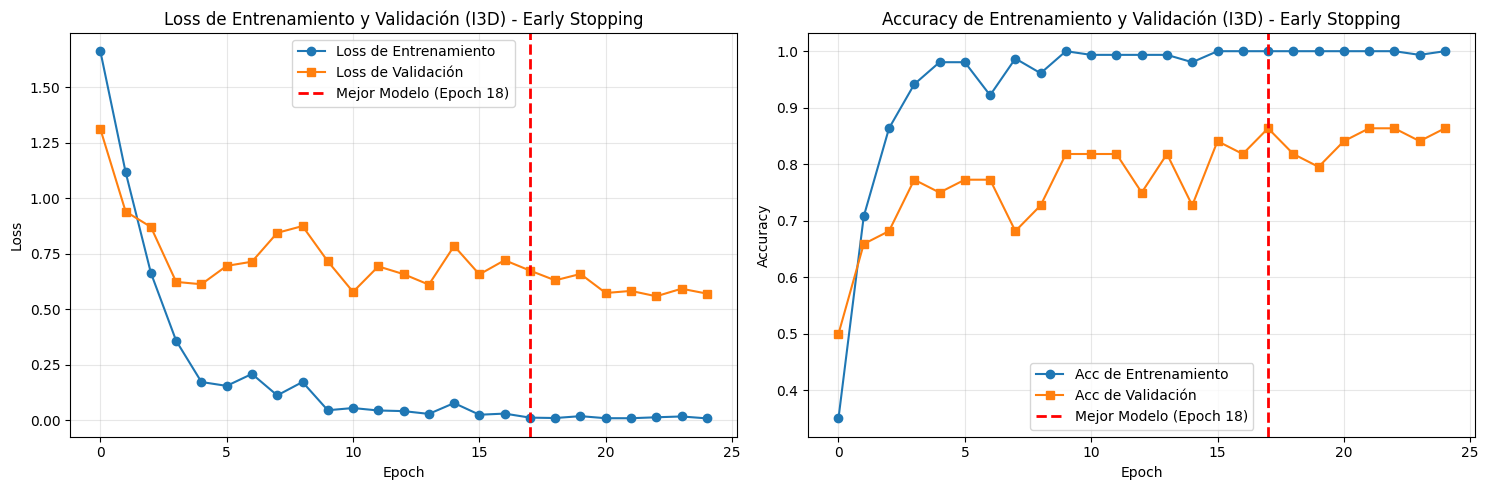


I3D - Test Set Evaluation
Test Loss: 0.8826, Test Acc: 0.739
Inference Time: 0.84 seconds (36.62 ms/sample)

Classification Report:
                 precision    recall  f1-score   support

       Backhand      0.500     0.500     0.500         4
Backhand_Volley      0.833     1.000     0.909         5
       Forehand      0.333     0.333     0.333         3
Forehand_Volley      1.000     0.500     0.667         4
          Smash      1.000     1.000     1.000         4
 Vibora_Bandeja      0.750     1.000     0.857         3

       accuracy                          0.739        23
      macro avg      0.736     0.722     0.711        23
   weighted avg      0.757     0.739     0.730        23



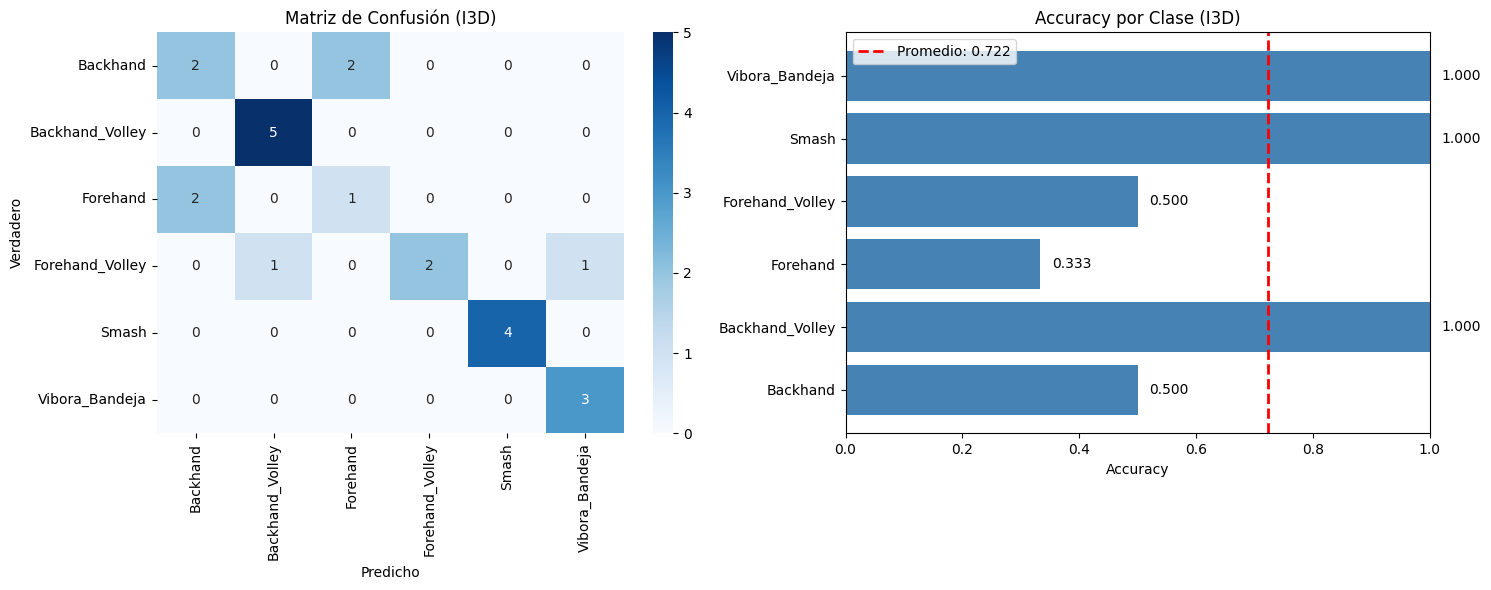

✓ Model saved locally: /content/artifacts/stroke_classification_video/i3d_final.pth
✓ Metadata saved locally: /content/artifacts/stroke_classification_video/i3d_metadata.json
✓ Model uploaded to gs://padel-cv-dataset/weights/i3d_final.pth
✓ Metadata uploaded to gs://padel-cv-dataset/weights/i3d_metadata.json


In [12]:
# Plot training curves
plot_training_curves(i3d_history, 'I3D')

# Evaluate on test set
i3d_acc, i3d_per_class, i3d_inference_time = evaluate_model(i3d_model, test_loader, train_dataset.labels, device, model_name='I3D')

# Save model and upload to GCS
save_and_upload_model(i3d_model, 'i3d', i3d_history, i3d_acc, i3d_per_class, i3d_inference_time, train_dataset.labels)


## 8. Model 2: SlowFast
Two-pathway network: slow pathway captures spatial semantics, fast pathway captures motion.

**Note:** SlowFast requires longer videos (≥32 frames with alpha=4) due to temporal pooling. This section will be skipped.

## 9. Model 3: TimeSformer (Video Transformer)
Divided space-time attention for video understanding. Using ViT-based adapter for demonstration.

In [13]:
# Create data loaders specifically for TimeSformer with a reduced batch size to the models fit in memory
train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=0)

# Load pretrained TimeSformer from HuggingFace
print('Loading TimeSformer from HuggingFace...')
timesformer_model_base = TimesformerForVideoClassification.from_pretrained(
    "facebook/timesformer-base-finetuned-k400"
)

# Replace classification head for our task
timesformer_model_base.classifier = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(timesformer_model_base.config.hidden_size, num_classes)
)

timesformer_model = timesformer_model_base.to(device)
print(f'TimeSformer model loaded. Trainable params: {sum(p.numel() for p in timesformer_model.parameters() if p.requires_grad):,}')

# Adapter to convert our data format to TimeSformer input format
class TimeSformerAdapter(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, x):
        # x: (B, C, T, H, W) - our format
        # TimeSformer expects: (B, T, C, H, W)
        B, C, T, H, W = x.shape
        x = x.permute(0, 2, 1, 3, 4)  # (B, T, C, H, W)

        # TimeSformer expects pixel_values in this format
        outputs = self.base_model(pixel_values=x)
        return outputs.logits

timesformer_adapted = TimeSformerAdapter(timesformer_model).to(device)

# Train with early stopping
timesformer_adapted, timesformer_history = train_model(
    timesformer_adapted, train_loader, val_loader,
    epochs=30, lr=1e-4, model_name='timesformer', patience=7
)

Loading TimeSformer from HuggingFace...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


TimeSformer model loaded. Trainable params: 121,263,366
Epoch 01/30  loss: 1.7327 - acc: 0.3182 - val_loss: 1.3115 - val_acc: 0.5227 - lr: 1.00e-04 **
Epoch 02/30  loss: 1.0138 - acc: 0.6429 - val_loss: 1.1499 - val_acc: 0.4773 - lr: 9.97e-05
Epoch 03/30  loss: 0.6186 - acc: 0.7208 - val_loss: 0.7766 - val_acc: 0.6591 - lr: 9.89e-05 **
Epoch 04/30  loss: 0.6304 - acc: 0.7727 - val_loss: 0.9156 - val_acc: 0.5909 - lr: 9.76e-05
Epoch 05/30  loss: 0.3445 - acc: 0.9026 - val_loss: 1.1807 - val_acc: 0.6136 - lr: 9.57e-05
Epoch 06/30  loss: 0.3544 - acc: 0.8896 - val_loss: 0.9812 - val_acc: 0.5909 - lr: 9.33e-05
Epoch 07/30  loss: 0.1844 - acc: 0.9416 - val_loss: 1.7330 - val_acc: 0.5682 - lr: 9.05e-05
Epoch 08/30  loss: 0.1368 - acc: 0.9675 - val_loss: 1.0203 - val_acc: 0.6364 - lr: 8.72e-05
Epoch 09/30  loss: 0.0848 - acc: 0.9740 - val_loss: 1.0086 - val_acc: 0.6136 - lr: 8.35e-05
Epoch 10/30  loss: 0.0540 - acc: 0.9805 - val_loss: 1.0313 - val_acc: 0.7273 - lr: 7.94e-05 **
Epoch 11/30  lo

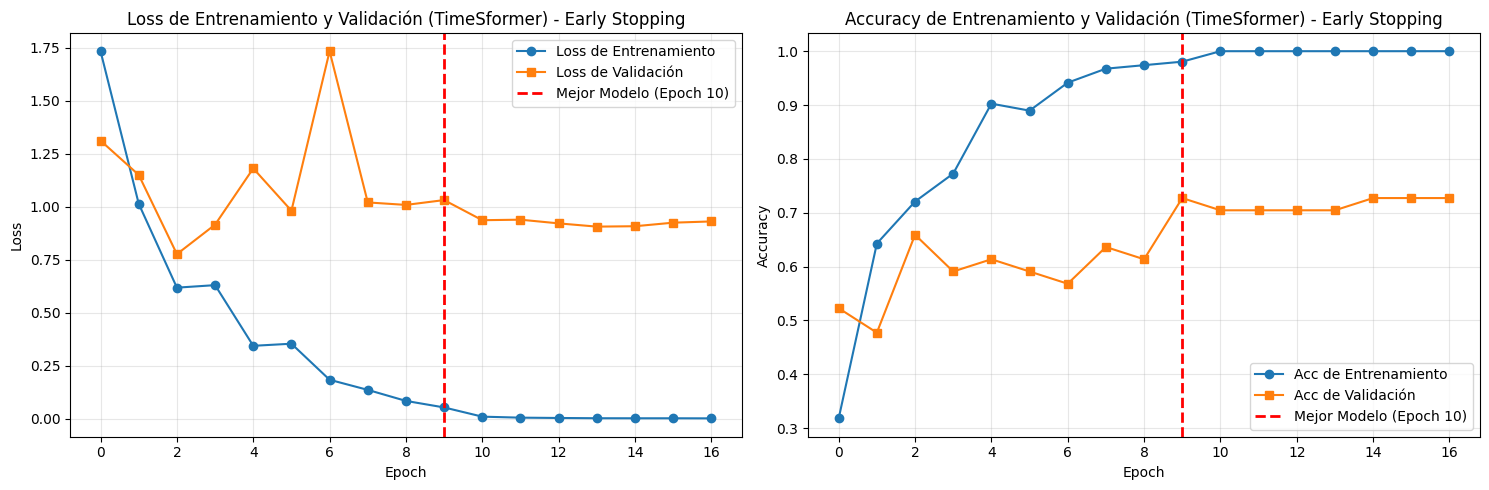


TimeSformer - Test Set Evaluation
Test Loss: 0.5150, Test Acc: 0.913
Inference Time: 4.19 seconds (182.20 ms/sample)

Classification Report:
                 precision    recall  f1-score   support

       Backhand      0.667     1.000     0.800         4
Backhand_Volley      1.000     1.000     1.000         5
       Forehand      1.000     0.333     0.500         3
Forehand_Volley      1.000     1.000     1.000         4
          Smash      1.000     1.000     1.000         4
 Vibora_Bandeja      1.000     1.000     1.000         3

       accuracy                          0.913        23
      macro avg      0.944     0.889     0.883        23
   weighted avg      0.942     0.913     0.900        23



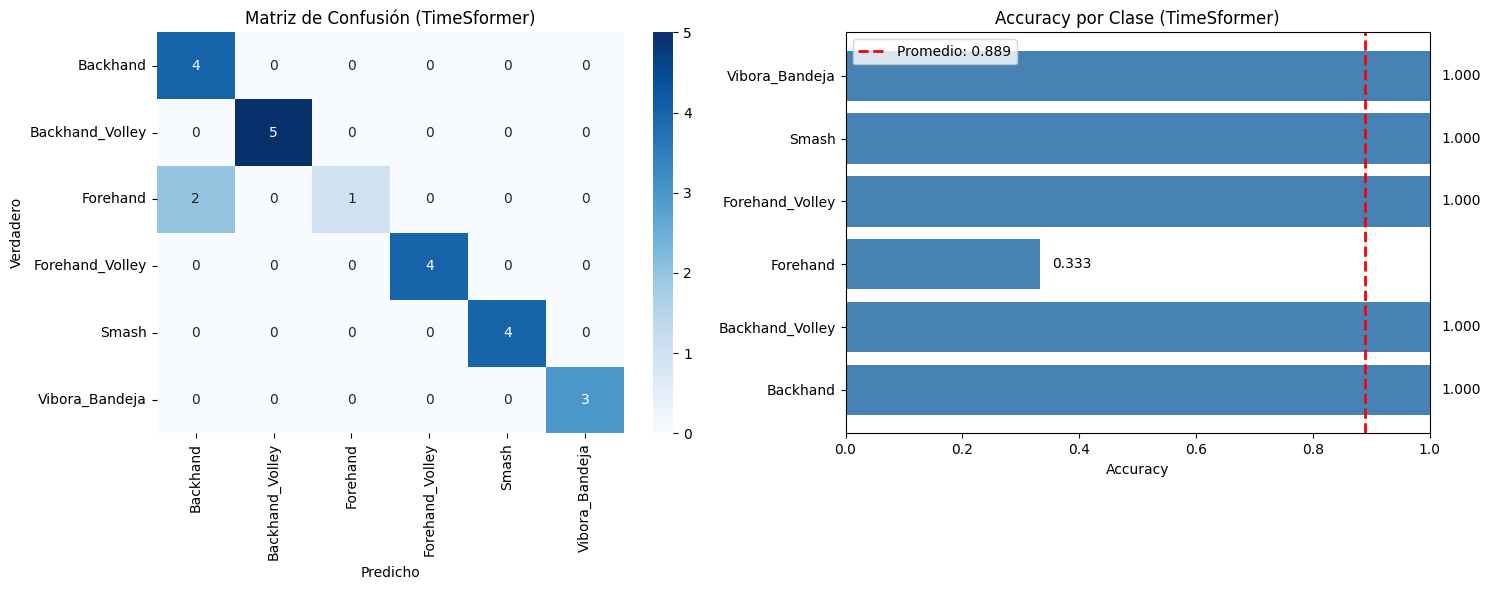

✓ Model saved locally: /content/artifacts/stroke_classification_video/timesformer_final.pth
✓ Metadata saved locally: /content/artifacts/stroke_classification_video/timesformer_metadata.json
✓ Model uploaded to gs://padel-cv-dataset/weights/timesformer_final.pth
✓ Metadata uploaded to gs://padel-cv-dataset/weights/timesformer_metadata.json


In [14]:
# Plot training curves
plot_training_curves(timesformer_history, 'TimeSformer')

# Evaluate on test set
timesformer_acc, timesformer_per_class, timesformer_inference_time = evaluate_model(
    timesformer_adapted, test_loader, train_dataset.labels, device, model_name='TimeSformer'
)

# Save model and upload to GCS
save_and_upload_model(timesformer_adapted, 'timesformer', timesformer_history, timesformer_acc, timesformer_per_class, timesformer_inference_time, train_dataset.labels)


## 10. Test set evaluation
Evaluate all three models on the held-out test set.

I3D                 : 0.739
TimeSformer         : 0.913


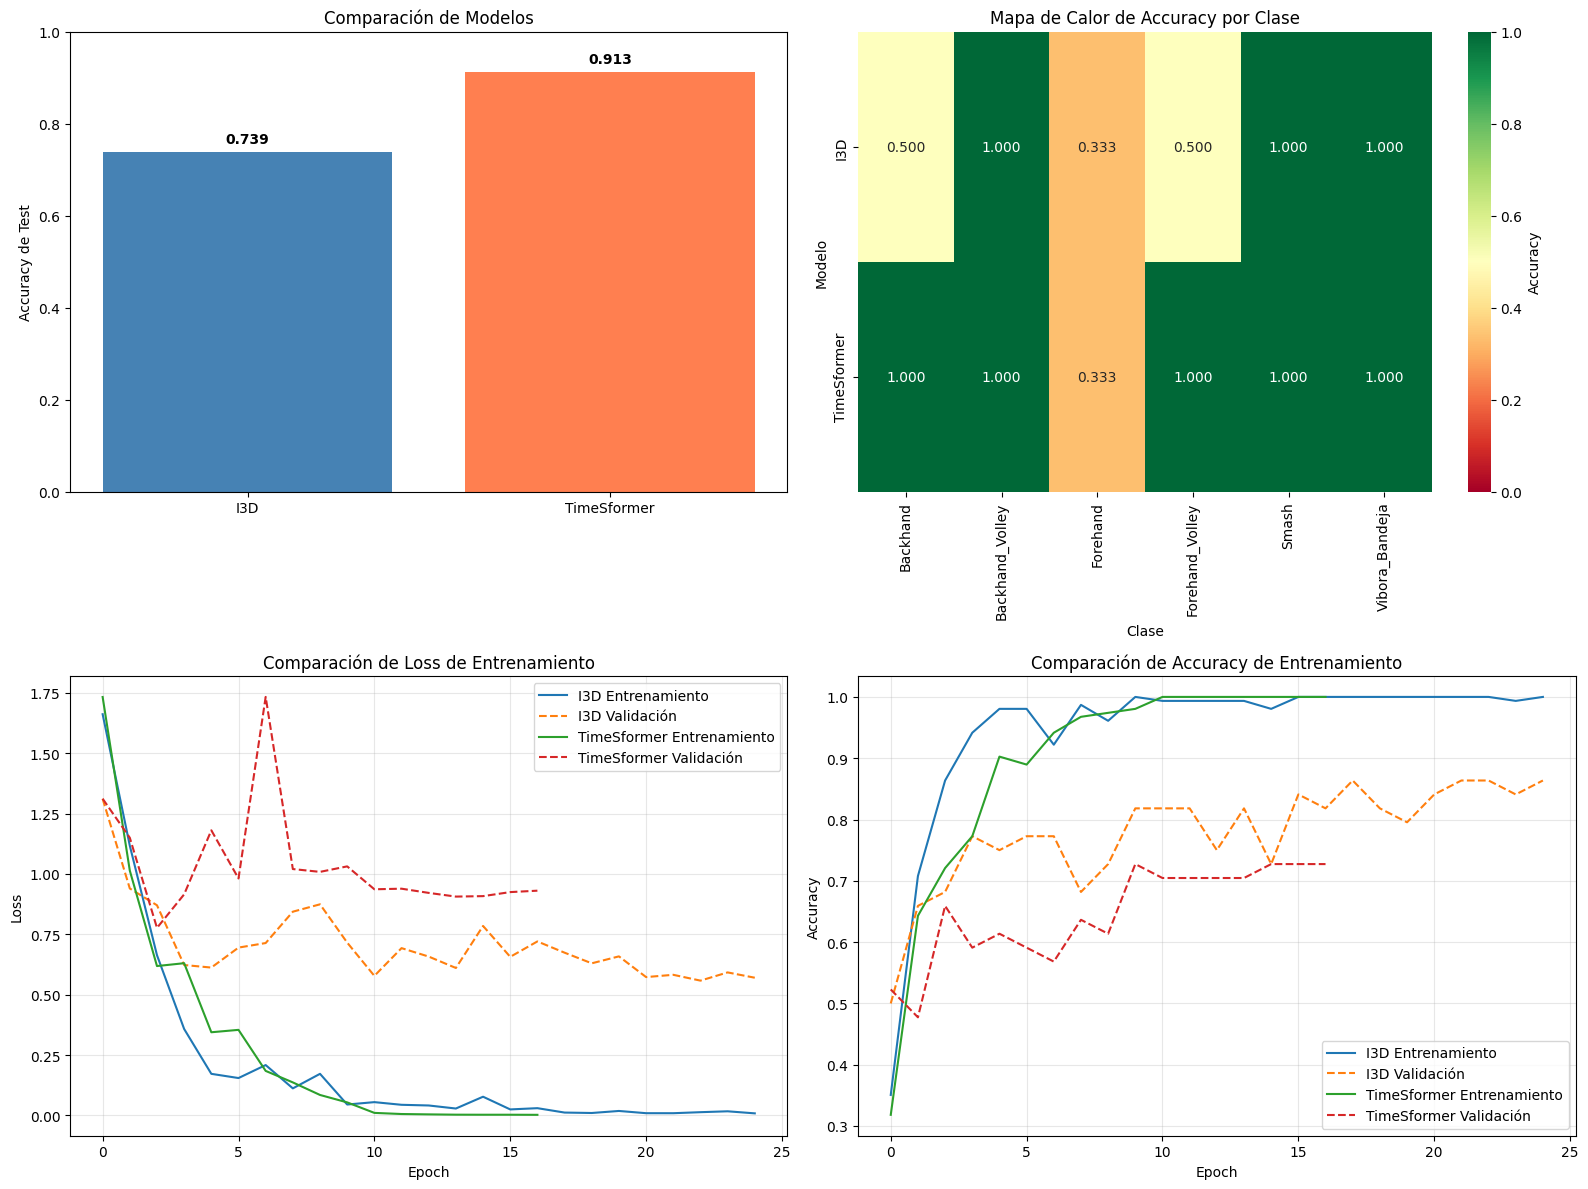

In [15]:
# Collect all results
results = {
    'I3D': i3d_acc,
    'TimeSformer': timesformer_acc,
}

per_class_results = {
    'I3D': i3d_per_class,
    'TimeSformer': timesformer_per_class,
}

# Summary
for model_name, acc in results.items():
    print(f'{model_name:20s}: {acc:.3f}')

# Comparative visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Model accuracy comparison
model_names = list(results.keys())
accuracies = list(results.values())
axes[0, 0].bar(model_names, accuracies, color=['steelblue', 'coral', 'mediumseagreen'][:len(model_names)])
axes[0, 0].set_ylabel('Accuracy de Test')
axes[0, 0].set_title('Comparación de Modelos')
axes[0, 0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0, 0].text(i, v + 0.02, f'{v:.3f}', ha='center', fontweight='bold')

# 2. Per-class accuracy heatmap
per_class_matrix = np.array([per_class_results[m] for m in model_names])
sns.heatmap(per_class_matrix, annot=True, fmt='.3f', cmap='RdYlGn',
            xticklabels=train_dataset.labels, yticklabels=model_names,
            vmin=0, vmax=1, ax=axes[0, 1], cbar_kws={'label': 'Accuracy'})
axes[0, 1].set_title('Mapa de Calor de Accuracy por Clase')
axes[0, 1].set_xlabel('Clase')
axes[0, 1].set_ylabel('Modelo')

# 3. Training loss comparison
for model_name in model_names:
    if model_name == 'I3D':
        axes[1, 0].plot(i3d_history['train_loss'], label=f'{model_name} Entrenamiento', linestyle='-')
        axes[1, 0].plot(i3d_history['val_loss'], label=f'{model_name} Validación', linestyle='--')
    elif model_name == 'TimeSformer' and timesformer_history is not None:
        axes[1, 0].plot(timesformer_history['train_loss'], label=f'{model_name} Entrenamiento', linestyle='-')
        axes[1, 0].plot(timesformer_history['val_loss'], label=f'{model_name} Validación', linestyle='--')

axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Comparación de Loss de Entrenamiento')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# 4. Training accuracy comparison
for model_name in model_names:
    if model_name == 'I3D':
        axes[1, 1].plot(i3d_history['train_acc'], label=f'{model_name} Entrenamiento', linestyle='-')
        axes[1, 1].plot(i3d_history['val_acc'], label=f'{model_name} Validación', linestyle='--')
    elif model_name == 'TimeSformer' and timesformer_history is not None:
        axes[1, 1].plot(timesformer_history['train_acc'], label=f'{model_name} Entrenamiento', linestyle='-')
        axes[1, 1].plot(timesformer_history['val_acc'], label=f'{model_name} Validación', linestyle='--')

axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Accuracy')
axes[1, 1].set_title('Comparación de Accuracy de Entrenamiento')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)


plt.tight_layout()
plt.show()